In [1]:
##в Дз рекомендуется продолжить датасет из 4й домашки, но я бы предпочел пройти весь путь заново и поработать с другим датасетом
##Датасет : https://www.kaggle.com/datasets/mirichoi0218/insurance/data

In [2]:
import pandas as pd
import missingno as mgno
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures, FunctionTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from scipy.stats import kstest, norm
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')

In [3]:
df = pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
#начнем с EDA и обучения линейной регрессии

In [5]:
##1й шаг нули и дупликаты

In [6]:
duplicates = df.duplicated()
df[duplicates]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


<Axes: >

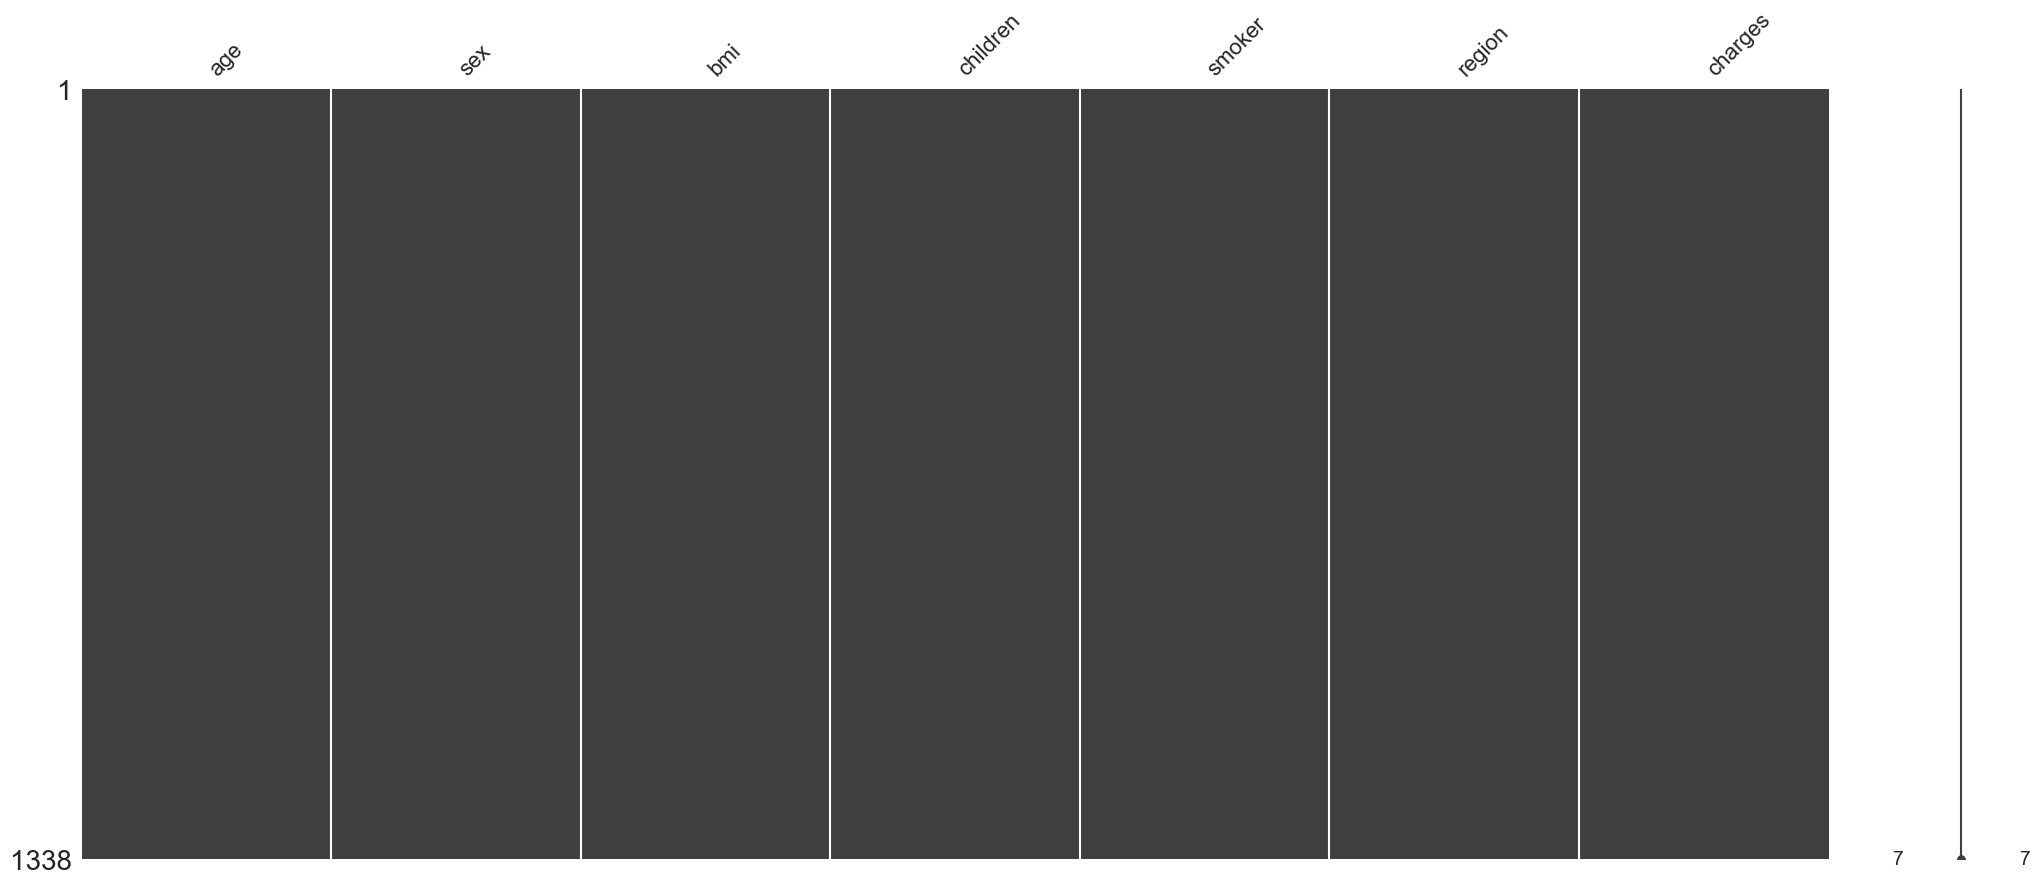

In [7]:
print(df.isnull().sum())
mgno.matrix(df)

In [8]:
##итого один дупликат м 0 пропусков, дупликаты просто выкинем

In [9]:
df = df.drop_duplicates()
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [10]:
###теперь рассмотрим выбросы
df_numeric = df.select_dtypes(include='number')
df_numeric

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1333,50,30.970,3,10600.54830
1334,18,31.920,0,2205.98080
1335,18,36.850,0,1629.83350
1336,21,25.800,0,2007.94500


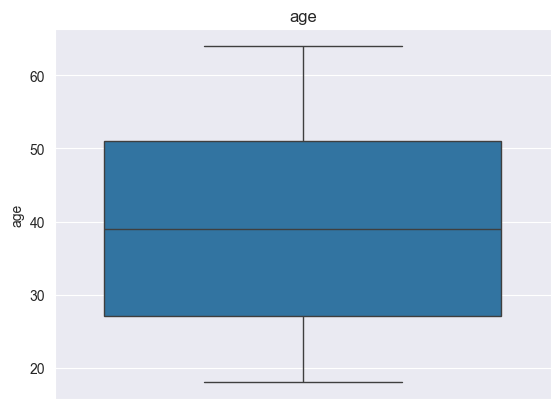

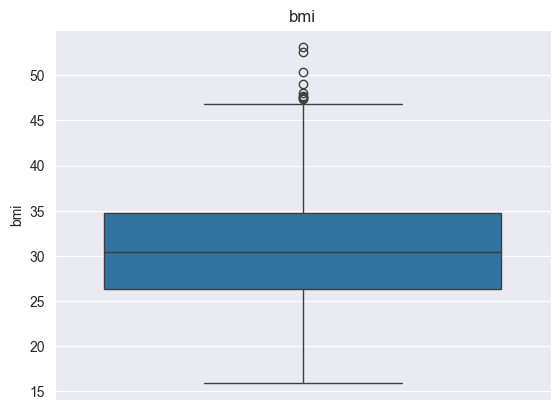

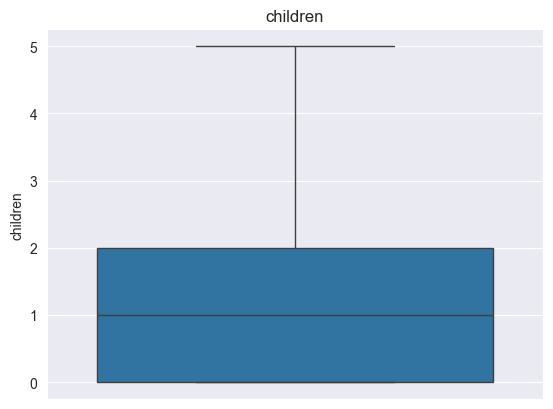

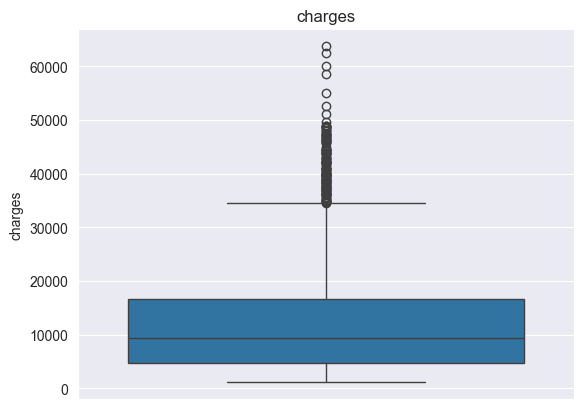

In [11]:
for column in df_numeric.columns :
    plt.figure()
    plt.title(column)
    sns.boxplot(df_numeric[column])

<Axes: ylabel='charges'>

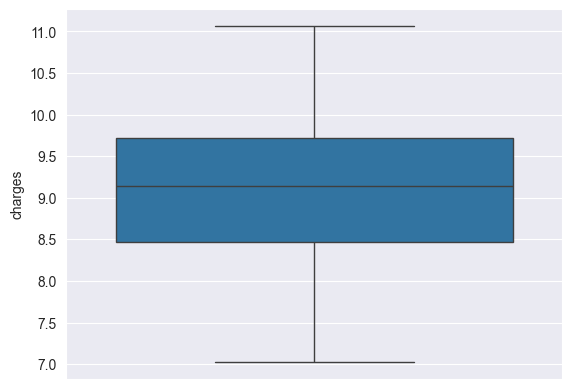

In [12]:
###из-за огромного числа выбросов в таргете, будет сложно обучить линейную регрессию, + дополнительно необходимо провести преобразование
###выполнем логарифмическое преобразование
df['charges'] = np.log(df['charges'])
plt.figure
sns.boxplot(df['charges'])

In [13]:
strs = df.select_dtypes(include= 'str')
for str in strs :
    print(pd.unique(strs[str]))

<StringArray>
['female', 'male']
Length: 2, dtype: str
<StringArray>
['yes', 'no']
Length: 2, dtype: str
<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str


In [14]:
##теперь было бы неплохо закодировать фичи, будем использовать OHE
df_encoded = pd.get_dummies(df,columns=(df.select_dtypes(include= 'str').columns),dtype= int, drop_first= True)
df_encoded

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,9.734176,0,1,0,0,1
1,18,33.770,1,7.453302,1,0,0,1,0
2,28,33.000,3,8.400538,1,0,0,1,0
3,33,22.705,0,9.998092,1,0,1,0,0
4,32,28.880,0,8.260197,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,9.268661,1,0,1,0,0
1334,18,31.920,0,7.698927,0,0,0,0,0
1335,18,36.850,0,7.396233,0,0,0,1,0
1336,21,25.800,0,7.604867,0,0,0,0,1


In [15]:
##попробуем обучить теперь модель
X = df_encoded.drop(columns= 'charges')
y = df_encoded['charges']
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size= 0.2 , random_state=42)

In [23]:
Linear_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(2)),
    ('model', LinearRegression())
])
Linear_pipe.fit(X_train,y_train)
prdct = Linear_pipe.predict(X_test)
metrics = {'r2_score' : r2_score(y_test,prdct),
          'MSE' : mean_squared_error(y_test,prdct),
          'MAE' : mean_absolute_error(y_test,prdct),
          'MAPE' : mean_absolute_percentage_error(y_test,prdct)}
metrics = pd.Series(metrics).to_frame(name='Score_LR')
metrics
print(cross_val_score(Linear_pipe,X,y, cv =5,))


[0.87986956 0.7352603  0.90476313 0.83090141 0.8121073 ]


In [22]:
#теперь поработаем со случайным лесом
#для случайного леса практиечски не важна будет строгая предобработка со скейлером и т.п., т.к. основан на решаюших деревьях , 
#которые в отличие от линейной регрессиии не являются строгой математической моделью
#случайный лес без гиперпараметров
rf = RandomForestRegressor()
rf.fit(X_train,y_train)
rf_prdct = rf.predict(X_test)
metrics2 = {'r2_score' : r2_score(y_test,rf_prdct),
          'MSE' : mean_squared_error(y_test,rf_prdct),
          'MAE' : mean_absolute_error(y_test,rf_prdct),
          'MAPE' : mean_absolute_percentage_error(y_test,rf_prdct)}
metrics2 = pd.Series(metrics2).to_frame(name='Score_rf')
metrics2

,Score_rf
r2_score,0.849393
MSE,0.139790
MAE,0.198849
MAPE,0.022374


In [18]:
###теперь займемся подбором гиперпараметров
rf_params = {'bootstrap': [True],
 'max_depth': [10, 20, 30, None],
 'max_features': ['auto', 'sqrt', 1/3],
 'min_samples_leaf': [1, 2, 4],
 'min_samples_split': [2, 5, 10],
 'n_estimators': [200, 400, 600, 800, 1000]}

###юудем использоваать RandomizedSearch, быстрее чем GridSearch
rf_b = RandomForestRegressor()
rf_random = RandomizedSearchCV(rf_b,param_distributions= rf_params, n_iter = 200, cv =5,random_state=42, n_jobs = -1)
rf_random.fit(X_train,y_train)
rf_random.best_params_

{'n_estimators': 800,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 0.3333333333333333,
 'max_depth': 10,
 'bootstrap': True}

In [20]:
rf_best = rf_random.best_estimator_
rf_predict = rf_best.predict(X_test)
metrics3 = {'r2_score' : r2_score(y_test,rf_predict),
          'MSE' : mean_squared_error(y_test,rf_predict),
          'MAE' : mean_absolute_error(y_test,rf_predict),
          'MAPE' : mean_absolute_percentage_error(y_test,rf_predict)}
metrics3 = pd.Series(metrics3).to_frame(name='Score_rf_best')
metrics3
print(cross_val_score(rf_best,X,y,cv =5))
print(metrics3)

[0.85794753 0.73242976 0.8719252  0.82120558 0.80858973]
          Score_rf_best
r2_score       0.857284
MSE            0.132466
MAE            0.227679
MAPE           0.025242


In [21]:
#теперь обучим дерево, одно дерево как правило будет обучаться быстрее. но если есть возможность построить все деревья паралелльно(случайный лес
#строит деревья независимо друг от друга. что позволяет распараллелить все это дело, и при большом количестве ресурсов будет +- одинаковое время
des_tree = DecisionTreeRegressor(max_depth=10)
des_tree.fit(X_train,y_train)
tree_predict = des_tree.predict(X_test)
metrics4 = {'r2_score' : r2_score(y_test,tree_predict),
          'MSE' : mean_squared_error(y_test,tree_predict),
          'MAE' : mean_absolute_error(y_test,tree_predict),
          'MAPE' : mean_absolute_percentage_error(y_test,tree_predict)}
metrics4 = pd.Series(metrics4).to_frame(name='Score_Tree')
metrics4
print(cross_val_score(des_tree,X,y,cv =5))
print(metrics4)

[0.76832663 0.602187   0.69315662 0.75104451 0.74905211]
          Score_Tree
r2_score    0.811010
MSE         0.175416
MAE         0.202361
MAPE        0.022354


In [26]:
#теперь выведем финальную таблицу результатов и сравним
metrics_all = [metrics,metrics2,metrics3,metrics4]
results_df = pd.concat(metrics_all,axis = 1)
results_df

,Score_LR,Score_rf,Score_rf_best,Score_Tree
r2_score,0.886004,0.849393,0.857284,0.811010
MSE,0.105809,0.139790,0.132466,0.175416
MAE,0.197116,0.198849,0.227679,0.202361
MAPE,0.021669,0.022374,0.025242,0.022354


In [31]:
##теперь посмотрим Lr без PolynomialFeatures
Linear_pipe_np = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
Linear_pipe_np.fit(X_train,y_train)
prdct_np = Linear_pipe_np.predict(X_test)
metricsl = {'r2_score' : r2_score(y_test,prdct_np),
          'MSE' : mean_squared_error(y_test,prdct_np),
          'MAE' : mean_absolute_error(y_test,prdct_np),
          'MAPE' : mean_absolute_percentage_error(y_test,prdct_np)}
metricsl = pd.Series(metricsl).to_frame(name='Score_LR_np')
print(cross_val_score(Linear_pipe_np,X,y, cv =5,))
metricsl

[0.79835905 0.68674419 0.83078382 0.76842848 0.73446625]


,Score_LR_np
r2_score,0.829464
MSE,0.158288
MAE,0.260702
MAPE,0.028932


In [30]:
metrics_al = [metrics,metricsl,metrics2,metrics3,metrics4]
final_df = pd.concat(metrics_al,axis =1)
final_df

,Score_LR,Score_LR_np,Score_rf,Score_rf_best,Score_Tree
r2_score,0.886004,0.829464,0.849393,0.857284,0.811010
MSE,0.105809,0.158288,0.139790,0.132466,0.175416
MAE,0.197116,0.260702,0.198849,0.227679,0.202361
MAPE,0.021669,0.028932,0.022374,0.025242,0.022354


ЛР является лучшей моделью в данной ситуации по метрикам, тут очень сильно вытягивает PolynomialFeatures, если его убрать результат будут значительно хуже, можно сазать что здесь есть очень сильная нелинейная зависимость, основной метрикой для подбора модели был $R^2$, коэффициент детерминации, объясняющий какая часть дисперсии моделью объясняется непосредственно самой моделью

В данном ноутбуке использовали кросс-валидацию и выборку обычно делят на 5 частей, что позволяет нам проверить на каждой части и получить представление о переобученности нашей модели, но метод съедает значительное количество ресурсов и мы в качестве альтернативы два раза применить train_test_split, делим на train+val  и тест, потом соответсвенно на train и val